In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
winequality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = winequality.data.features 
y = winequality.data.targets 

In [3]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [4]:
from experiment import run_parallel_experiments

n_trees_settings = [20, 50, 100, 200]

all_results = {}

for n_trees in n_trees_settings:
    notebook_name = f"real2_WineQuality_ntrees{n_trees}"
    print(f"Running: {notebook_name} (n_trees={n_trees})")

    results = run_parallel_experiments(
        X=X,
        y=y,
        ndpost=7000,
        nskip=3000,           # burn-in
        n_trees=n_trees,
        notebook=notebook_name,
        tree_alpha=0.95,
        tree_beta=2.0,
        m_tries=10,
        n_runs=3, # TODO: Increase to 5 or more
        n_chains=4,
        n_jobs=-2,
        base_split_seed=42,
        base_chain_seed=2026,
        store_preds=True,
        n_test_points=100,
        start_temp=1.0,
        end_temp=1.0,
        store_dir="store"
    )

    all_results[notebook_name] = results

print("All n_trees settings finished.")

Running: real2_WineQuality_ntrees200 (n_trees=200)


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 72.8min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 72.9min remaining: 72.9min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 73.2min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 90.1min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 90.7min remaining: 90.7min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 91.2min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 91.3min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 91.4min remaining: 91.4min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 91.6min finished


All n_trees settings finished.


# Results

Using STORE_DIR: C:\Users\ztykk\Phd\BART\bart-playground\diagnosis\n-trees\store
Detected n_trees: [20, 50, 100, 200]
Detected runs: [0, 1, 2]
Top-5 MTMH single-iteration RMSE per run (chain pooled)
run000


,run,n_trees,chain,iteration,rmse
0,run000,200,0,2298,0.599543
1,run000,200,0,1836,0.607750
2,run000,200,0,2330,0.610115
3,run000,200,0,2297,0.610879
4,run000,200,0,1835,0.615978


run001


,run,n_trees,chain,iteration,rmse
0,run001,100,0,1633,0.671671
1,run001,100,0,1632,0.677004
2,run001,50,3,260,0.677542
3,run001,50,3,262,0.677878
4,run001,50,3,1122,0.678952


run002


...

Combined RMSE comparison table (MTMH + baselines + MTMH_BestIter)


,run000,run001,run002
MTMH_n_trees=20,0.678057,0.734673,0.653182
MTMH_n_trees=50,0.683513,0.720410,0.644236
MTMH_n_trees=100,0.688367,0.737622,0.634860
MTMH_n_trees=200,0.682549,0.738151,0.644453
XGBoost_200,0.631541,0.699573,0.619559
TabPFN,0.576445,0.673633,0.644214
MTMH_BestIter,0.599543,0.671671,0.583004


Combined CRPS comparison table (MTMH + TabPFN baseline)


,run000,run001,run002
MTMH_n_trees=20,0.366772,0.406120,0.366719
MTMH_n_trees=50,0.369303,0.400104,0.362277
MTMH_n_trees=100,0.371637,0.409077,0.355647
MTMH_n_trees=200,0.368305,0.409502,0.362460
TabPFN,0.239104,0.319279,0.313788



===== Run 000 =====


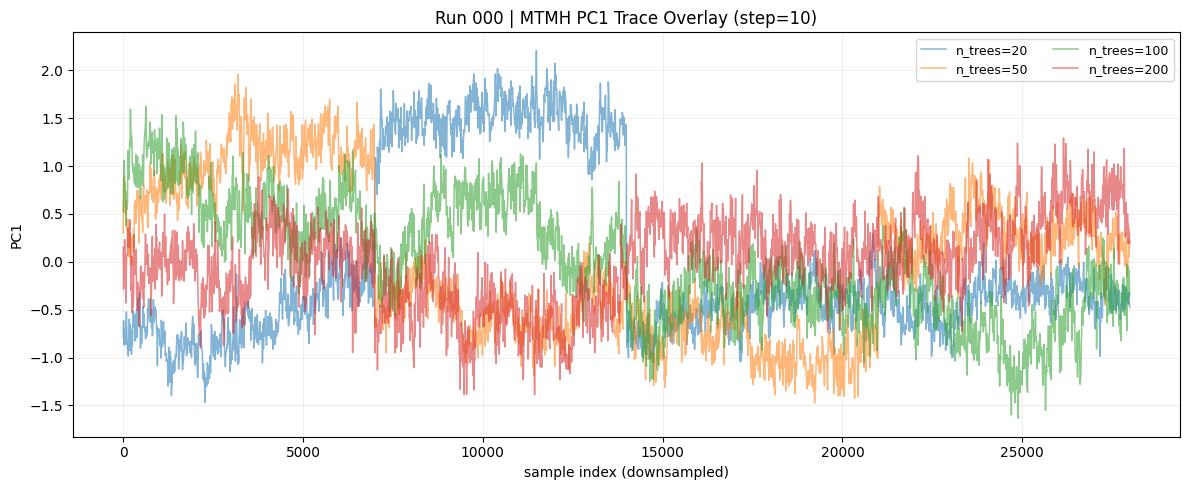

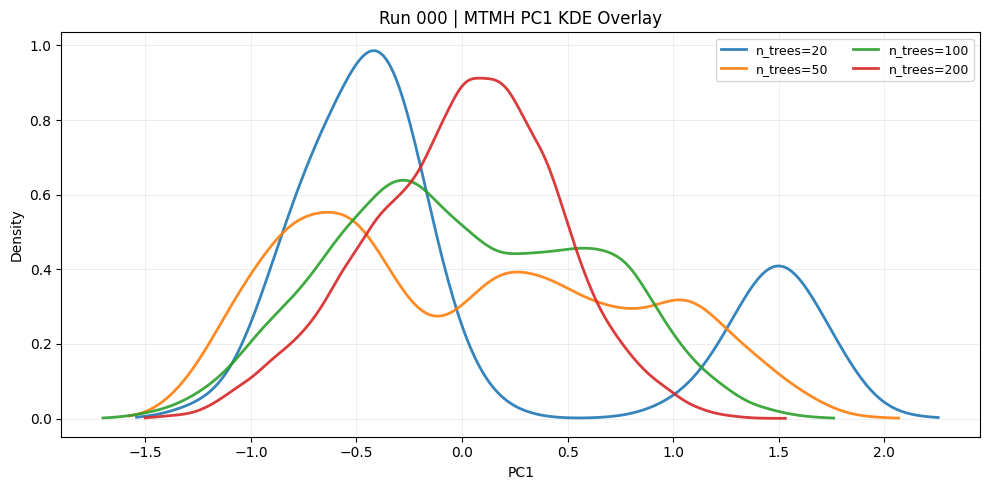

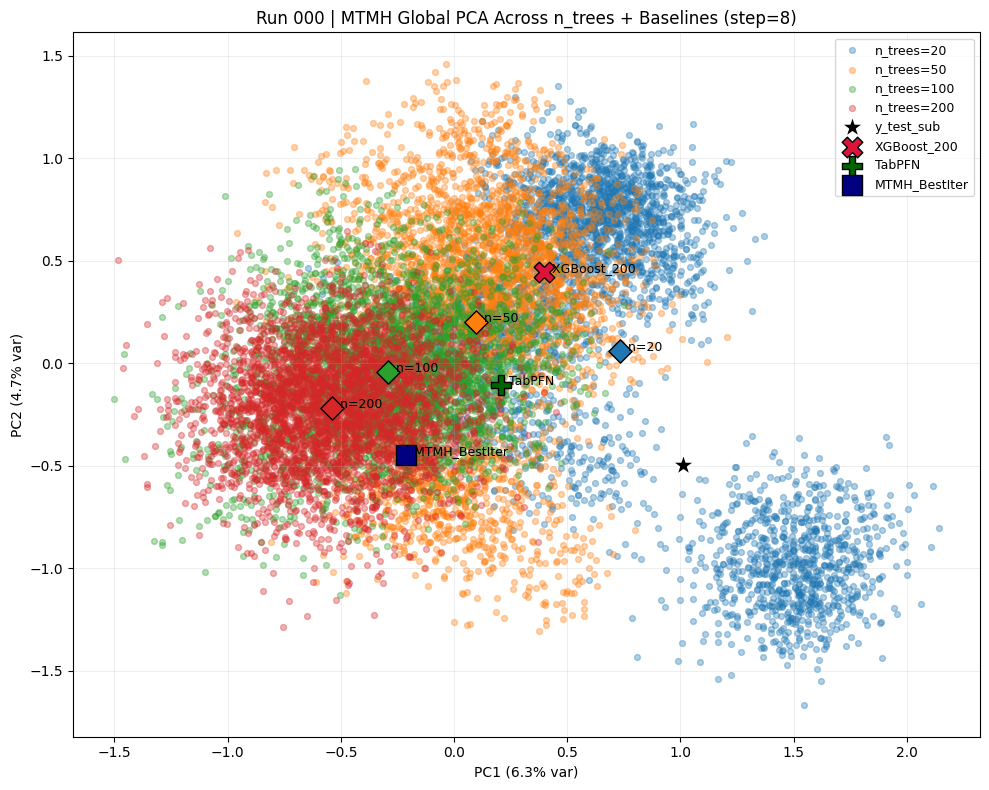


===== Run 001 =====


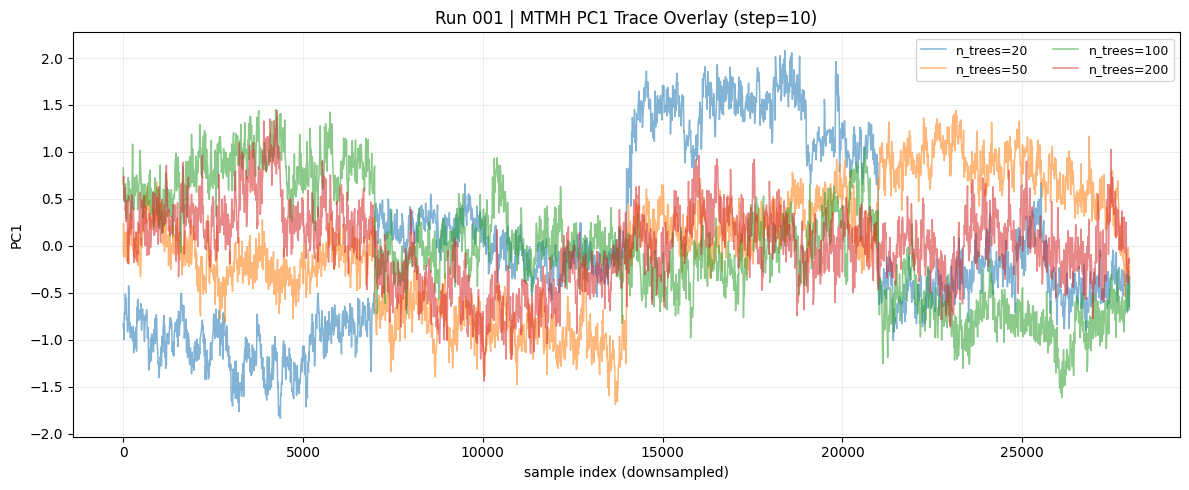

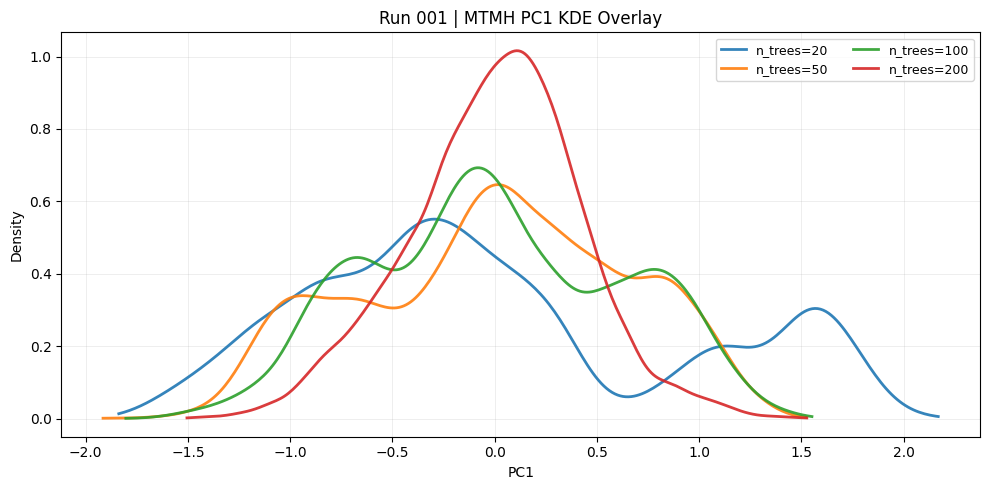

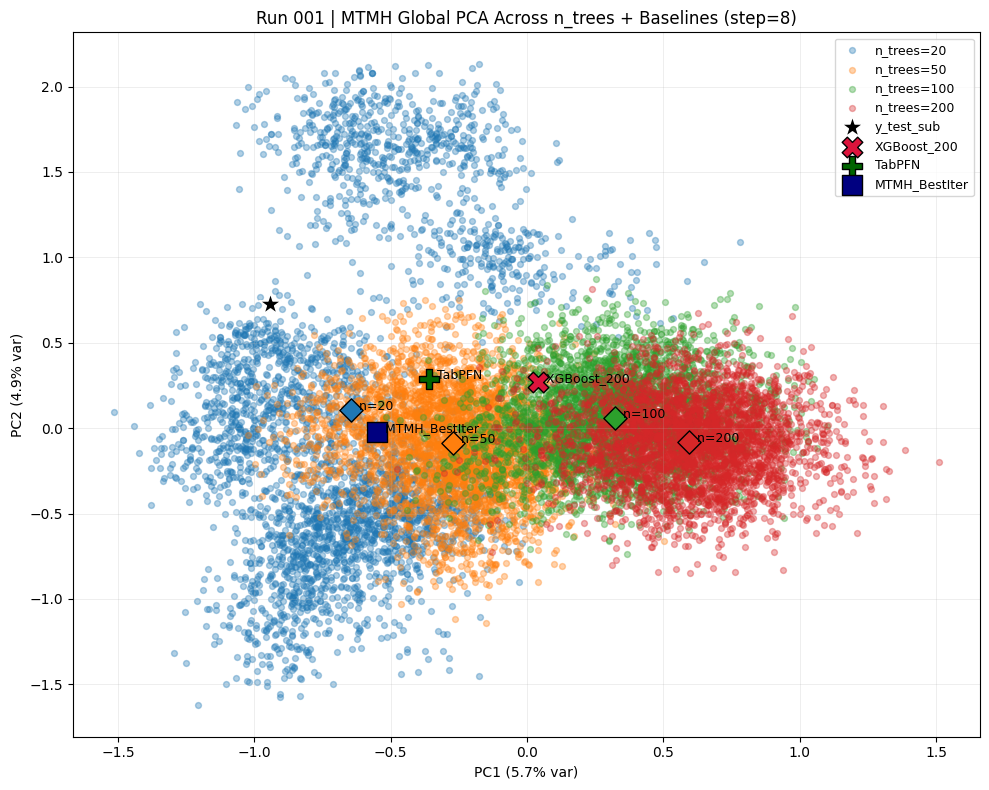


===== Run 002 =====


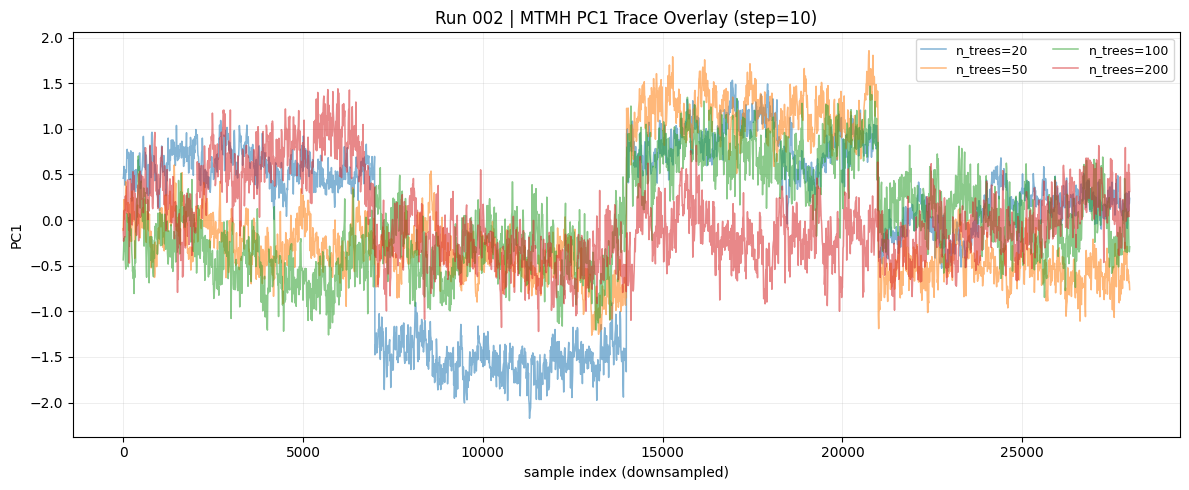

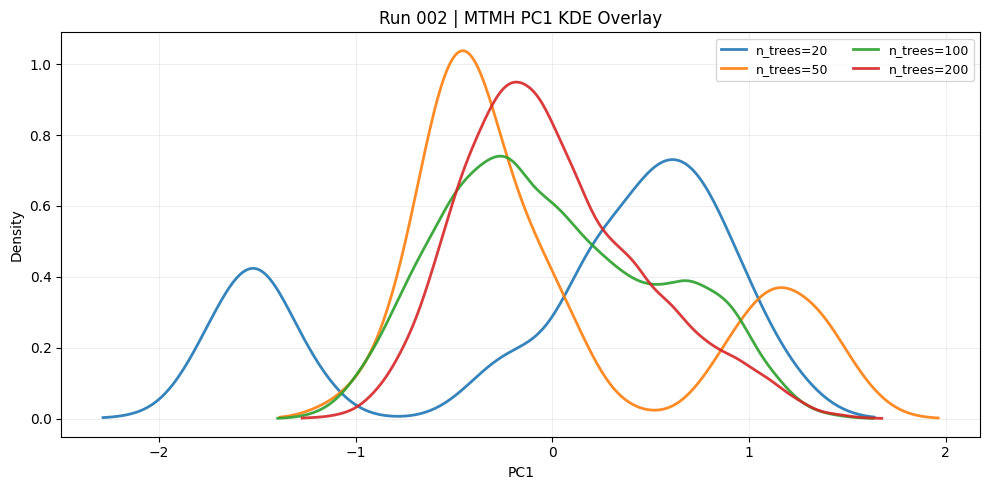

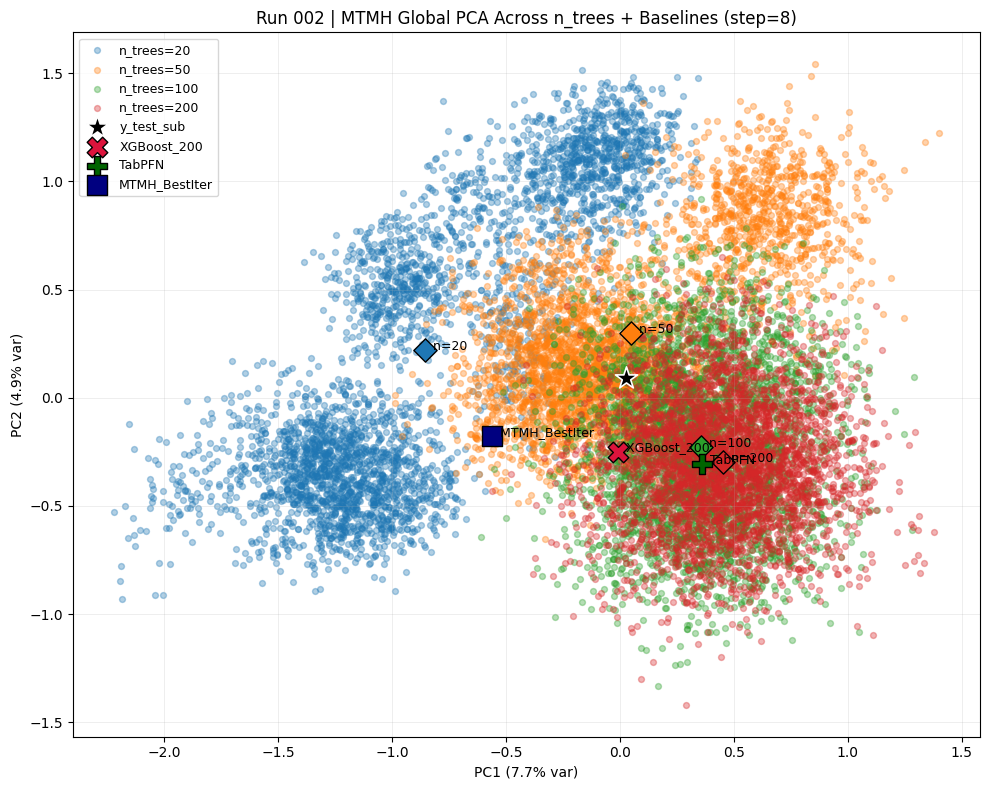

In [5]:
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from tabpfn import TabPFNRegressor

NOTEBOOK_PREFIX = "real2_WineQuality"
STORE_DIR = Path("store")
BASE_SPLIT_SEED = 42

XGB_TREES = 200
XGB_VAL_FRACTION = 0.2
XGB_EARLY_STOPPING_ROUNDS = 20
TABPFN_CRPS_QUANTILES = np.linspace(0.01, 0.99, 99)

print("Using STORE_DIR:", STORE_DIR.resolve())


def _parse_shape_from_header(csv_path):
    with open(csv_path, "r", encoding="utf-8") as f:
        first_line = f.readline().strip()
    first_line = first_line.lstrip("#").strip()
    if not first_line.startswith("original_shape="):
        raise ValueError(f"Missing original_shape header in {csv_path}")
    return ast.literal_eval(first_line.split("=", 1)[1].strip())


def load_saved_numeric_csv(csv_path):
    shape = _parse_shape_from_header(csv_path)
    arr2d = np.loadtxt(csv_path, delimiter=",", comments="#")
    if arr2d.size == 0:
        return np.array([])
    if arr2d.ndim == 0:
        arr2d = arr2d.reshape(1, 1)
    elif arr2d.ndim == 1:
        arr2d = arr2d.reshape(1, -1)
    return arr2d.reshape(shape)


def discover_ntrees_and_runs(prefix=NOTEBOOK_PREFIX):
    rmse_dir = STORE_DIR / "subsample_rmse"
    pattern = re.compile(
        rf"^{re.escape(prefix)}_ntrees(?P<ntrees>\d+)__run(?P<run>\d{{3}})__mtmh__subsample_rmse\.csv$"
    )
    ntrees_to_runs = {}
    for p in rmse_dir.glob(f"{prefix}_ntrees*__mtmh__subsample_rmse.csv"):
        m = pattern.match(p.name)
        if m is None:
            continue
        n_trees = int(m.group("ntrees"))
        run = int(m.group("run"))
        ntrees_to_runs.setdefault(n_trees, set()).add(run)

    if not ntrees_to_runs:
        sample_files = [q.name for q in rmse_dir.glob("*__mtmh__subsample_rmse.csv")][:10]
        raise FileNotFoundError(
            f"No MTMH files found in {rmse_dir} for prefix '{prefix}'. "
            f"Sample MTMH files in this dir: {sample_files}"
        )

    ntrees = sorted(ntrees_to_runs.keys())
    runs = sorted(set().union(*ntrees_to_runs.values()))
    return ntrees, runs


def build_metric_pivots(ntrees, runs, prefix=NOTEBOOK_PREFIX):
    rmse_pivot = pd.DataFrame(index=ntrees, columns=[f"run{r:03d}" for r in runs], dtype=float)
    crps_pivot = pd.DataFrame(index=ntrees, columns=[f"run{r:03d}" for r in runs], dtype=float)

    for run_id in runs:
        for n_trees in ntrees:
            base = f"{prefix}_ntrees{n_trees}__run{run_id:03d}"
            rmse_path = STORE_DIR / "subsample_rmse" / f"{base}__mtmh__subsample_rmse.csv"
            crps_path = STORE_DIR / "subsample_crps" / f"{base}__mtmh__subsample_crps.csv"
            if not (rmse_path.exists() and crps_path.exists()):
                continue

            rmse_vals = load_saved_numeric_csv(rmse_path).reshape(-1)
            crps_vals = load_saved_numeric_csv(crps_path).reshape(-1)
            rmse_pivot.loc[n_trees, f"run{run_id:03d}"] = float(np.mean(rmse_vals))
            crps_pivot.loc[n_trees, f"run{run_id:03d}"] = float(np.mean(crps_vals))

    return rmse_pivot, crps_pivot


def load_mtmh_preds_for_ntrees_run(n_trees, run_id, prefix=NOTEBOOK_PREFIX):
    base = f"{prefix}_ntrees{n_trees}__run{run_id:03d}"
    pred_path = STORE_DIR / "preds" / f"{base}__mtmh__preds.csv"
    if not pred_path.exists():
        return None
    return load_saved_numeric_csv(pred_path)  # [n_chains, n_test, ndpost]


def load_y_test_sub_for_run(run_id, ntrees, prefix=NOTEBOOK_PREFIX):
    for n_trees in ntrees:
        p = STORE_DIR / "subsample_y_test" / f"{prefix}_ntrees{n_trees}__run{run_id:03d}__subsample_y_test.csv"
        if p.exists():
            return load_saved_numeric_csv(p).reshape(-1)
    return None


def load_x_test_sub_for_run(run_id, ntrees, prefix=NOTEBOOK_PREFIX):
    for n_trees in ntrees:
        p = STORE_DIR / "subsample_X_test" / f"{prefix}_ntrees{n_trees}__run{run_id:03d}__subsample_X_test.csv"
        if p.exists():
            return load_saved_numeric_csv(p)
    return None


def preds_to_matrix(preds):
    # [n_chains, n_test, ndpost] -> [n_chains * ndpost, n_test]
    n_chains, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(n_chains * ndpost, n_test)


def collect_pc_matrices_for_run(run_id, ntrees, prefix=NOTEBOOK_PREFIX):
    mats = {}
    for n_trees in ntrees:
        preds = load_mtmh_preds_for_ntrees_run(n_trees, run_id, prefix=prefix)
        if preds is None:
            continue
        mats[n_trees] = preds_to_matrix(preds)
    return mats


def _crps_from_quantiles(y_true, quantile_levels, quantile_preds):
    y = np.asarray(y_true).reshape(1, -1)
    q = np.asarray(quantile_levels)
    qp = np.asarray(quantile_preds)

    if qp.ndim != 2:
        raise ValueError("quantile_preds must be 2D")

    if qp.shape[0] == q.shape[0]:
        qmat = qp
    elif qp.shape[1] == q.shape[0]:
        qmat = qp.T
    else:
        raise ValueError(
            f"Quantile prediction shape mismatch: qp.shape={qp.shape}, n_quantiles={q.shape[0]}"
        )

    q_col = q.reshape(-1, 1)
    u = y - qmat
    pinball = np.where(u >= 0.0, q_col * u, (q_col - 1.0) * u)
    crps_per_point = 2.0 * np.trapezoid(pinball, q, axis=0)
    return crps_per_point


def _fit_xgboost_for_run(X_train, y_train, run_id):
    model = XGBRegressor(
        n_estimators=XGB_TREES,
        learning_rate=0.05,
        max_depth=6,
        early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
        random_state=BASE_SPLIT_SEED + run_id,
        n_jobs=-1,
    )

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train,
        y_train,
        test_size=XGB_VAL_FRACTION,
        random_state=10000 + run_id,
    )

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    return model


def _fit_tabpfn_for_run(X_train, y_train, run_id):
    model = TabPFNRegressor(random_state=BASE_SPLIT_SEED + run_id, ignore_pretraining_limits=True)
    model.fit(X_train, y_train)
    return model


def find_topk_mtmh_iterations_for_run(run_id, ntrees, topk=5, prefix=NOTEBOOK_PREFIX):
    y_test_sub = load_y_test_sub_for_run(run_id, ntrees, prefix=prefix)
    if y_test_sub is None:
        return pd.DataFrame(), None, None

    records = []
    best_pred = None
    best_rmse = np.inf

    for n_trees in ntrees:
        preds = load_mtmh_preds_for_ntrees_run(n_trees, run_id, prefix=prefix)
        if preds is None:
            continue

        n_chains, _, ndpost = preds.shape
        for chain_id in range(n_chains):
            for iter_id in range(ndpost):
                pred_vec = preds[chain_id, :, iter_id]
                rmse_val = float(root_mean_squared_error(y_test_sub, pred_vec))
                records.append(
                    {
                        "run": f"run{run_id:03d}",
                        "n_trees": int(n_trees),
                        "chain": int(chain_id),
                        "iteration": int(iter_id),
                        "rmse": rmse_val,
                    }
                )

                if rmse_val < best_rmse:
                    best_rmse = rmse_val
                    best_pred = np.asarray(pred_vec).reshape(-1)

    if not records:
        return pd.DataFrame(), None, None

    topk_df = pd.DataFrame(records).sort_values("rmse", ascending=True).head(topk).reset_index(drop=True)
    best_row = topk_df.iloc[0].to_dict()
    return topk_df, best_row, best_pred


def train_baselines_for_run(run_id, ntrees, prefix=NOTEBOOK_PREFIX):
    split_seed = BASE_SPLIT_SEED + run_id
    X_train, _, y_train, _ = train_test_split(X, y, random_state=split_seed)

    X_test_sub = load_x_test_sub_for_run(run_id, ntrees, prefix=prefix)
    y_test_sub = load_y_test_sub_for_run(run_id, ntrees, prefix=prefix)

    if X_test_sub is None or y_test_sub is None:
        print(f"Run {run_id:03d}: missing subsample test data files, skip baselines.")
        return {}, []

    run_predictions = {}
    run_records = []

    xgb_model = _fit_xgboost_for_run(X_train, y_train, run_id)
    xgb_pred = np.asarray(xgb_model.predict(X_test_sub)).reshape(-1)
    xgb_rmse = float(root_mean_squared_error(y_test_sub, xgb_pred))
    run_predictions["XGBoost_200"] = xgb_pred
    run_records.append({"method": "XGBoost_200", "run": f"run{run_id:03d}", "rmse": xgb_rmse, "crps": np.nan})

    tabpfn_model = _fit_tabpfn_for_run(X_train, y_train, run_id)
    tabpfn_pred = np.asarray(tabpfn_model.predict(X_test_sub, output_type="mean")).reshape(-1)
    tabpfn_rmse = float(root_mean_squared_error(y_test_sub, tabpfn_pred))

    tabpfn_quantile_preds = tabpfn_model.predict(
        X_test_sub,
        output_type="quantiles",
        quantiles=TABPFN_CRPS_QUANTILES.tolist(),
    )
    tabpfn_crps = float(
        np.mean(
            _crps_from_quantiles(
                y_true=y_test_sub,
                quantile_levels=TABPFN_CRPS_QUANTILES,
                quantile_preds=tabpfn_quantile_preds,
            )
        )
    )

    run_predictions["TabPFN"] = tabpfn_pred
    run_records.append({"method": "TabPFN", "run": f"run{run_id:03d}", "rmse": tabpfn_rmse, "crps": tabpfn_crps})

    return run_predictions, run_records


def build_rmse_comparison_table(mtmh_rmse_pivot, baseline_records):
    comparison = mtmh_rmse_pivot.copy()
    comparison.index = [f"MTMH_n_trees={int(n)}" for n in comparison.index]

    if baseline_records:
        baseline_df = pd.DataFrame(baseline_records)
        baseline_pivot = baseline_df.pivot(index="method", columns="run", values="rmse")
        baseline_order = ["XGBoost_200", "TabPFN", "MTMH_BestIter"]
        baseline_pivot = baseline_pivot.reindex(baseline_order).dropna(how="all")
        baseline_pivot = baseline_pivot.reindex(columns=comparison.columns)
        comparison = pd.concat([comparison, baseline_pivot], axis=0)

    return comparison


def build_crps_comparison_table(mtmh_crps_pivot, baseline_records):
    comparison = mtmh_crps_pivot.copy()
    comparison.index = [f"MTMH_n_trees={int(n)}" for n in comparison.index]

    if baseline_records:
        baseline_df = pd.DataFrame(baseline_records)
        baseline_df = baseline_df.dropna(subset=["crps"])
        if not baseline_df.empty:
            baseline_pivot = baseline_df.pivot(index="method", columns="run", values="crps")
            baseline_order = ["TabPFN"]
            baseline_pivot = baseline_pivot.reindex(baseline_order).dropna(how="all")
            baseline_pivot = baseline_pivot.reindex(columns=comparison.columns)
            comparison = pd.concat([comparison, baseline_pivot], axis=0)

    return comparison


def plot_pc1_trace_overlay(run_id, mats, ntrees, downsample_step=10):
    if not mats:
        print(f"Run {run_id:03d}: no MTMH prediction files found, skip PC1 trace.")
        return

    palette = plt.get_cmap("tab10")
    plt.figure(figsize=(12, 5))
    for i, n_trees in enumerate(ntrees):
        if n_trees not in mats:
            continue
        pc1 = PCA(n_components=1).fit_transform(mats[n_trees])[:, 0]
        idx = np.arange(pc1.shape[0])[::downsample_step]
        plt.plot(
            idx,
            pc1[idx],
            alpha=0.55,
            linewidth=1.1,
            color=palette(i % 10),
            label=f"n_trees={n_trees}",
        )

    plt.title(f"Run {run_id:03d} | MTMH PC1 Trace Overlay (step={downsample_step})")
    plt.xlabel("sample index (downsampled)")
    plt.ylabel("PC1")
    plt.grid(alpha=0.25, linewidth=0.6)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_pc1_kde_overlay(run_id, mats, ntrees):
    if not mats:
        print(f"Run {run_id:03d}: no MTMH prediction files found, skip PC1 KDE.")
        return

    palette = plt.get_cmap("tab10")
    plt.figure(figsize=(10, 5))
    for i, n_trees in enumerate(ntrees):
        if n_trees not in mats:
            continue
        pc1 = PCA(n_components=1).fit_transform(mats[n_trees])[:, 0]
        if pc1.size < 2 or np.std(pc1) == 0:
            continue
        kde = gaussian_kde(pc1)
        xgrid = np.linspace(np.min(pc1), np.max(pc1), 300)
        plt.plot(
            xgrid,
            kde(xgrid),
            linewidth=2.0,
            alpha=0.9,
            color=palette(i % 10),
            label=f"n_trees={n_trees}",
        )

    plt.title(f"Run {run_id:03d} | MTMH PC1 KDE Overlay")
    plt.xlabel("PC1")
    plt.ylabel("Density")
    plt.grid(alpha=0.25, linewidth=0.6)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_pc1_pc2_scatter_global_pca(
    run_id,
    mats,
    ntrees,
    baseline_points=None,
    prefix=NOTEBOOK_PREFIX,
    downsample_step=8,
):
    if not mats:
        print(f"Run {run_id:03d}: no MTMH prediction files found, skip PC1-PC2 scatter.")
        return

    available_ntrees = [n for n in ntrees if n in mats]
    X_all = np.vstack([mats[n] for n in available_ntrees])
    pca = PCA(n_components=2)
    pcs_all = pca.fit_transform(X_all)

    y_test_sub = load_y_test_sub_for_run(run_id, available_ntrees, prefix=prefix)
    y_proj = None
    if y_test_sub is not None and y_test_sub.shape[0] == X_all.shape[1]:
        y_proj = pca.transform(y_test_sub.reshape(1, -1))[0]

    palette = plt.get_cmap("tab10")
    color_map = {n: palette(i % 10) for i, n in enumerate(available_ntrees)}

    plt.figure(figsize=(10, 8))
    cursor = 0
    for n in available_ntrees:
        n_samples = mats[n].shape[0]
        idx_full = np.arange(cursor, cursor + n_samples)
        idx = idx_full[::downsample_step]
        pts = pcs_all[idx_full, :]

        plt.scatter(
            pcs_all[idx, 0],
            pcs_all[idx, 1],
            s=18,
            alpha=0.35,
            color=color_map[n],
            label=f"n_trees={n}",
        )

        centroid = pts.mean(axis=0)
        plt.scatter(
            centroid[0],
            centroid[1],
            s=140,
            color=color_map[n],
            edgecolors="black",
            linewidths=1.0,
            marker="D",
            zorder=6,
        )
        plt.text(
            centroid[0],
            centroid[1],
            f"  n={n}",
            fontsize=9,
            color="black",
            zorder=7,
        )

        cursor += n_samples

    if y_proj is not None:
        plt.scatter(
            y_proj[0],
            y_proj[1],
            s=280,
            c="black",
            marker="*",
            edgecolors="white",
            linewidths=1.2,
            label="y_test_sub",
            zorder=10,
        )

    if baseline_points:
        baseline_style = {
            "XGBoost_200": {"marker": "X", "color": "crimson", "size": 220},
            "TabPFN": {"marker": "P", "color": "darkgreen", "size": 220},
            "MTMH_BestIter": {"marker": "s", "color": "navy", "size": 220},
        }

        for method, pred_vector in baseline_points.items():
            pred_vector = np.asarray(pred_vector).reshape(-1)
            if pred_vector.shape[0] != X_all.shape[1]:
                print(
                    f"Run {run_id:03d}: {method} prediction length mismatch "
                    f"({pred_vector.shape[0]} vs {X_all.shape[1]}), skip point."
                )
                continue

            proj = pca.transform(pred_vector.reshape(1, -1))[0]
            style = baseline_style.get(method, {"marker": "^", "color": "gray", "size": 200})
            plt.scatter(
                proj[0],
                proj[1],
                s=style["size"],
                c=style["color"],
                marker=style["marker"],
                edgecolors="black",
                linewidths=1.0,
                label=method,
                zorder=11,
            )
            plt.text(
                proj[0],
                proj[1],
                f"  {method}",
                fontsize=9,
                color="black",
                zorder=12,
            )

    evr = pca.explained_variance_ratio_
    plt.xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
    plt.title(f"Run {run_id:03d} | MTMH Global PCA Across n_trees + Baselines (step={downsample_step})")
    plt.grid(alpha=0.25, linewidth=0.6)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), fontsize=9, loc="best")
    plt.tight_layout()
    plt.show()


ntrees, runs = discover_ntrees_and_runs(prefix=NOTEBOOK_PREFIX)
print("Detected n_trees:", ntrees)
print("Detected runs:", runs)

rmse_pivot, crps_pivot = build_metric_pivots(ntrees, runs, prefix=NOTEBOOK_PREFIX)

baseline_predictions_by_run = {}
baseline_rmse_records = []
top5_iterations_by_run = {}

for run_id in runs:
    run_preds, run_records = train_baselines_for_run(run_id, ntrees, prefix=NOTEBOOK_PREFIX)

    top5_df, best_row, best_pred = find_topk_mtmh_iterations_for_run(
        run_id, ntrees, topk=5, prefix=NOTEBOOK_PREFIX
    )
    top5_iterations_by_run[run_id] = top5_df

    if best_row is not None and best_pred is not None:
        run_preds["MTMH_BestIter"] = best_pred
        run_records.append(
            {
                "method": "MTMH_BestIter",
                "run": f"run{run_id:03d}",
                "rmse": float(best_row["rmse"]),
                "crps": np.nan,
            }
        )

    baseline_predictions_by_run[run_id] = run_preds
    baseline_rmse_records.extend(run_records)

print("Top-5 MTMH single-iteration RMSE per run (chain pooled)")
for run_id in runs:
    print(f"run{run_id:03d}")
    display(top5_iterations_by_run[run_id])

comparison_rmse = build_rmse_comparison_table(rmse_pivot, baseline_rmse_records)
print("Combined RMSE comparison table (MTMH + baselines + MTMH_BestIter)")
display(comparison_rmse)

comparison_crps = build_crps_comparison_table(crps_pivot, baseline_rmse_records)
print("Combined CRPS comparison table (MTMH + TabPFN baseline)")
display(comparison_crps)

for run_id in runs:
    print(f"\n===== Run {run_id:03d} =====")
    mats = collect_pc_matrices_for_run(run_id, ntrees, prefix=NOTEBOOK_PREFIX)

    # 1) PC1 trace plot: all n_trees on one canvas.
    plot_pc1_trace_overlay(run_id, mats, ntrees, downsample_step=10)

    # 2) PC1 KDE plot: all n_trees on one canvas.
    plot_pc1_kde_overlay(run_id, mats, ntrees)

    # 3) PC1 vs PC2 scatter: global PCA across all n_trees, with centroids, y_test_sub, and baseline models.
    plot_pc1_pc2_scatter_global_pca(
        run_id,
        mats,
        ntrees,
        baseline_points=baseline_predictions_by_run.get(run_id, {}),
        prefix=NOTEBOOK_PREFIX,
        downsample_step=8,
    )